<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


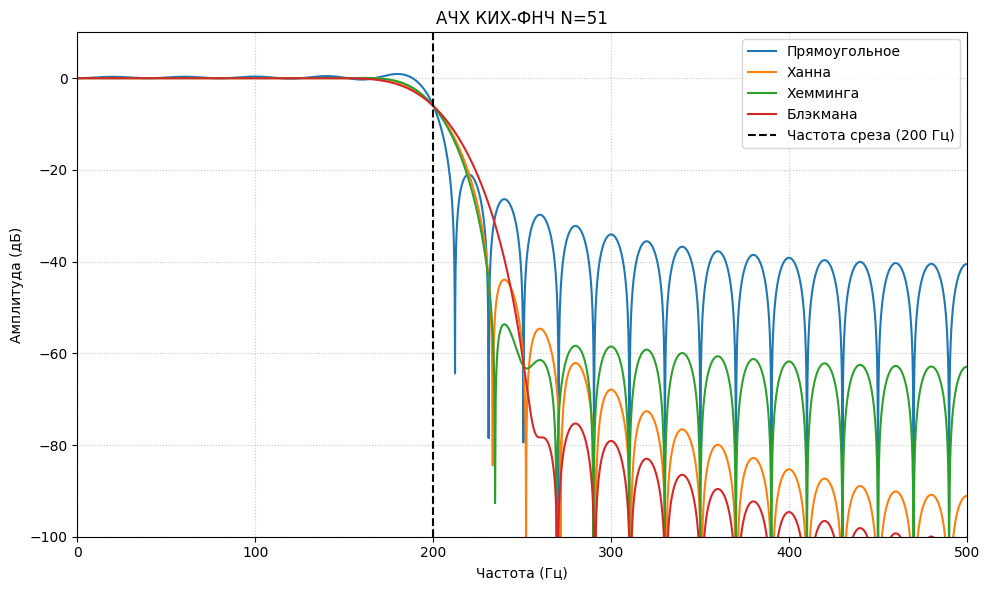

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import firwin, freqz, lfilter, remez, filtfilt, group_delay

fs = 1000.0
nyq = fs / 2.0
cutoff = 200.0
numtaps = 51

windows = {
    'Прямоугольное': 'boxcar',
    'Ханна': 'hann',
    'Хемминга': 'hamming',
    'Блэкмана': 'blackman'
}

plt.figure(figsize=(10, 6))

for label, win in windows.items():
    taps = firwin(numtaps, cutoff/nyq, window=win)

    w, h = freqz(taps, worN=8000)

    freqs = w * fs / (2 * np.pi)
    h_db = 20 * np.log10(np.maximum(np.abs(h), 1e-10))

    plt.plot(freqs, h_db, label=label)

plt.title('АЧХ КИХ-ФНЧ N=51')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', label='Частота среза (200 Гц)')
plt.ylim(-100, 10)
plt.xlim(0, fs/2)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

1 - Окно Блэкмана.
2 - Прямоугольнок окно.
3 - Чем плавнее окно спадает к краям, тем меньше боковые лепестки, но тем шире переходная полоса.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


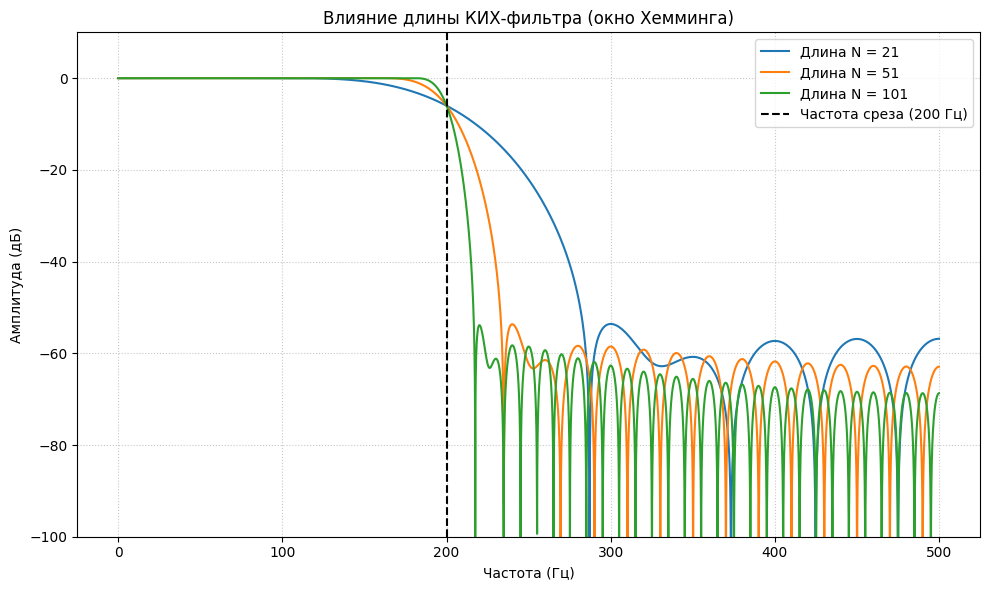

In [2]:
lengths = [21, 51, 101]

plt.figure(figsize=(10, 6))
for N in lengths:
    taps = firwin(N, cutoff/nyq, window='hamming')
    w, h = freqz(taps, worN=8000)
    freqs = w * fs / (2 * np.pi)

    h_db = 20 * np.log10(np.maximum(np.abs(h), 1e-10))
    plt.plot(freqs, h_db, label=f'Длина N = {N}')

plt.title('Влияние длины КИХ-фильтра (окно Хемминга)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(cutoff, color='k', linestyle='--', label='Частота среза (200 Гц)')
plt.ylim(-100, 10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

При увеличении длины фильтра переходная полоса сужается, поэтому срез становится круче. Уровень боковых лепестков определяется в основном самим окном, поэтому почти не меняется.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


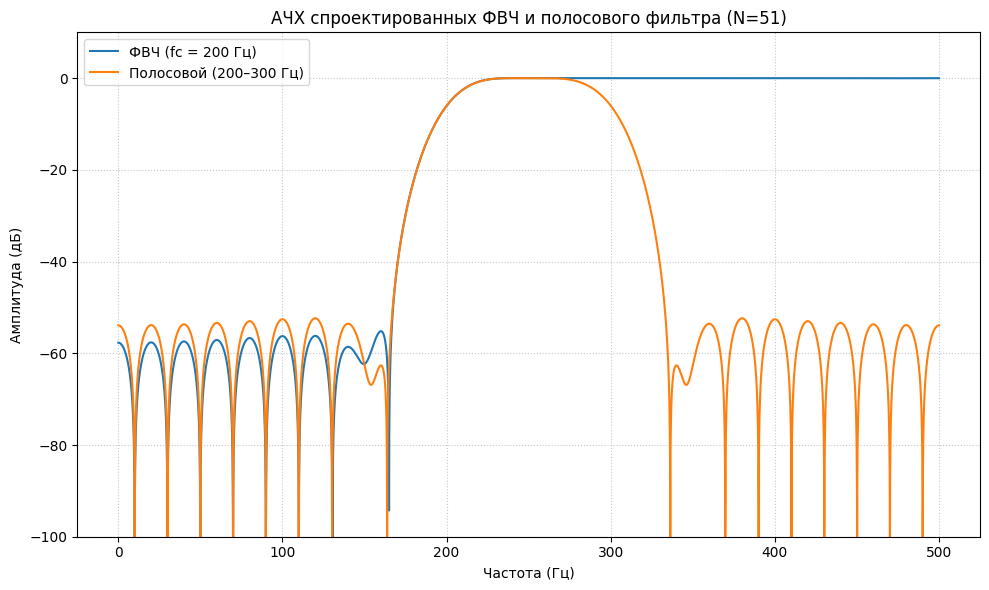

In [3]:
numtaps = 51

taps_hpf = firwin(numtaps, 200.0/nyq, window='hamming', pass_zero='highpass')

taps_bpf = firwin(numtaps, [200.0/nyq, 300.0/nyq], window='hamming', pass_zero='bandpass')

plt.figure(figsize=(10, 6))
for taps, label in [(taps_hpf, 'ФВЧ (fc = 200 Гц)'), (taps_bpf, 'Полосовой (200–300 Гц)')]:
    w, h = freqz(taps, worN=8000)
    freqs = w * fs / (2 * np.pi)
    plt.plot(freqs, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), label=label)

plt.title('АЧХ спроектированных ФВЧ и полосового фильтра (N=51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

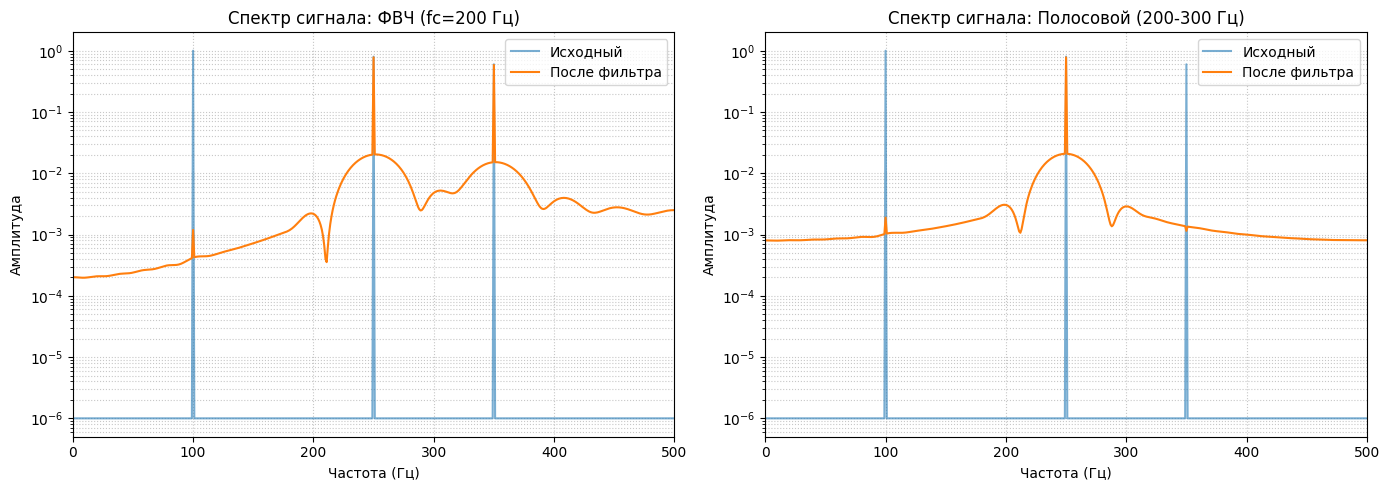

In [4]:
t = np.arange(0, 1.0, 1/fs)
sig = (1.0*np.sin(2*np.pi*100*t)
       + 0.8*np.sin(2*np.pi*250*t)
       + 0.6*np.sin(2*np.pi*350*t))

y_hpf = lfilter(taps_hpf, 1.0, sig)
y_bpf = lfilter(taps_bpf, 1.0, sig)

def amp_spectrum(x, fs):
    N = len(x)
    f = np.fft.rfftfreq(N, 1/fs)
    A = np.abs(np.fft.rfft(x)) / N * 2
    return f, A

f, A0 = amp_spectrum(sig, fs)
_, Ah = amp_spectrum(y_hpf, fs)
_, Ab = amp_spectrum(y_bpf, fs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.semilogy(f, np.maximum(A0, 1e-6), label='Исходный', alpha=0.6)
plt.semilogy(f, np.maximum(Ah, 1e-6), label='После фильтра')
plt.title('Спектр сигнала: ФВЧ (fc=200 Гц)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.xlim(0, fs/2)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(f, np.maximum(A0, 1e-6), label='Исходный', alpha=0.6)
plt.semilogy(f, np.maximum(Ab, 1e-6), label='После фильтра')
plt.title('Спектр сигнала: Полосовой (200-300 Гц)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.xlim(0, fs/2)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Объясните полученные результаты.

ФВЧ с fc=200 Гц подавляет составляющую 100 Гц и пропускает 250 и 350 Гц. Полосовой фильтр 200–300 Гц оставляет только 250 Гц, а 100 и 350 Гц подавляет.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

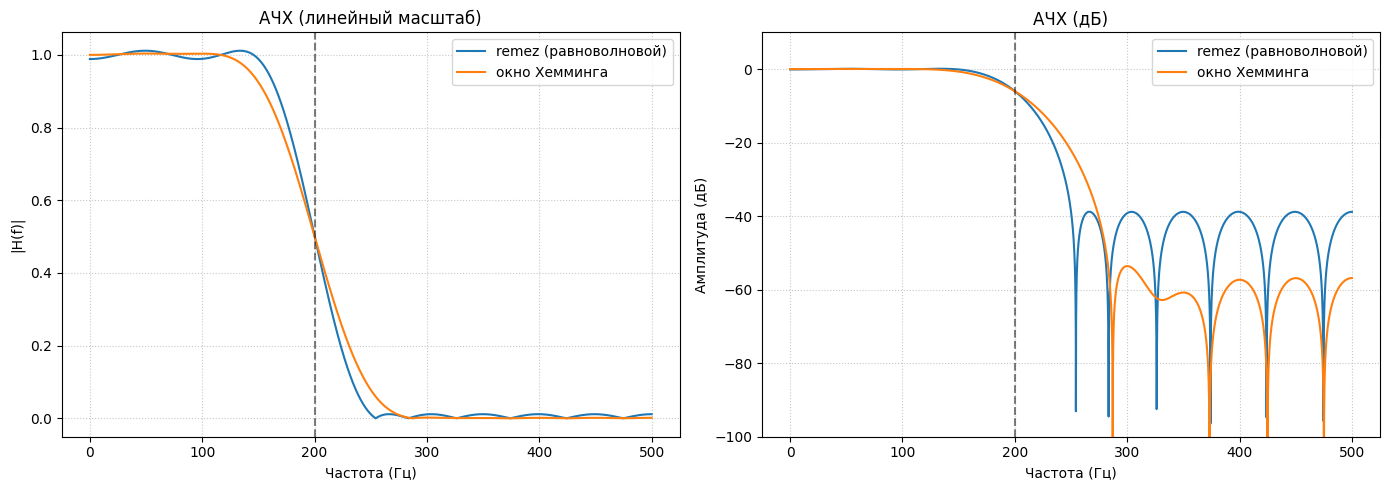

Фильтр            Пульсации ПП 0-150, дБ  Макс. ПЗ 250-500, дБ   Подавление ПЗ, дБ
remez                               0.20                 -38.8                38.8
окно Хемминга                       0.71                 -22.1                22.1


In [5]:
numtaps = 21

taps_remez = remez(numtaps, [0, 150, 250, 500], [1, 0], fs=fs)

taps_win = firwin(numtaps, 200.0, window='hamming', fs=fs)

w_r, h_r = freqz(taps_remez, worN=8000, fs=fs)
w_w, h_w = freqz(taps_win, worN=8000, fs=fs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(w_r, np.abs(h_r), label='remez (равноволновой)')
plt.plot(w_w, np.abs(h_w), label='окно Хемминга')
plt.axvline(200, color='k', ls='--', alpha=0.5)
plt.title('АЧХ (линейный масштаб)')
plt.xlabel('Частота (Гц)'); plt.ylabel('|H(f)|')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(w_r, 20*np.log10(np.maximum(np.abs(h_r), 1e-10)), label='remez (равноволновой)')
plt.plot(w_w, 20*np.log10(np.maximum(np.abs(h_w), 1e-10)), label='окно Хемминга')
plt.axvline(200, color='k', ls='--', alpha=0.5)
plt.title('АЧХ (дБ)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

print(f"{'Фильтр':<16}{'Пульсации ПП 0-150, дБ':>24}{'Макс. ПЗ 250-500, дБ':>22}{'Подавление ПЗ, дБ':>20}")
for name, h in [('remez', h_r), ('окно Хемминга', h_w)]:
    Hdb = 20*np.log10(np.maximum(np.abs(h), 1e-10))
    ripple = Hdb[w_r <= 150].max() - Hdb[w_r <= 150].min()
    stop = Hdb[w_r >= 250].max()
    print(f"{name:<16}{ripple:>24.2f}{stop:>22.1f}{-stop:>20.1f}")


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

При одинаковой длине более крутой срез у фильтра remez. Пульсации в полосе пропускания у него 0.2 дБ, тогда как у оконного Хемминга 0.71.

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


Хемминг: подавление на краю ПЗ (>=250 Гц) = -22.1 дБ; глубокая ПЗ (>=300 Гц) = -53.6 дБ
Совпадение с уровнем на краю ПЗ Хемминга (-22.1 дБ): Δ ≈ 46 Гц (подавление Remez -22.2 дБ)
Совпадение с глубоким уровнем ПЗ Хемминга (-53.6 дБ): Δ ≈ 148 Гц (подавление Remez -53.7 дБ)


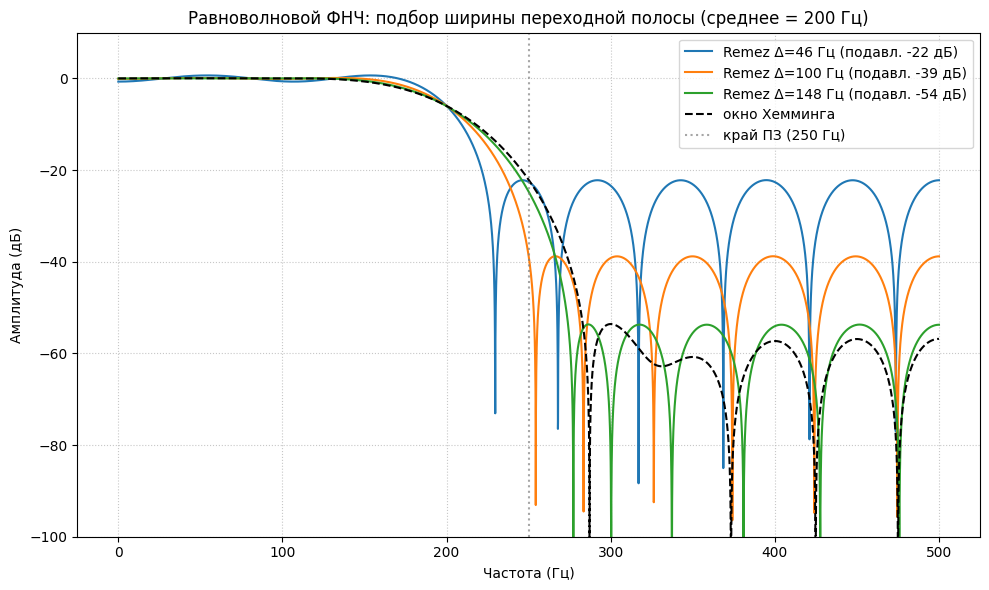

In [6]:
taps_win = firwin(21, 200.0, window='hamming', fs=fs)
w_w, h_w = freqz(taps_win, worN=8000, fs=fs)

ham_edge = 20*np.log10(np.max(np.abs(h_w[w_w >= 250])))
ham_floor = 20*np.log10(np.max(np.abs(h_w[w_w >= 300])))
print(f'Хемминг: подавление на краю ПЗ (>=250 Гц) = {ham_edge:.1f} дБ; '
      f'глубокая ПЗ (>=300 Гц) = {ham_floor:.1f} дБ')

numtaps = 21

def remez_stop(width):
    fpass, fstop = 200 - width/2, 200 + width/2
    taps = remez(numtaps, [0, fpass, fstop, 500], [1, 0], fs=fs)
    w, h = freqz(taps, worN=8000, fs=fs)
    return w, h, 20*np.log10(np.max(np.abs(h[w >= fstop])))

widths = np.arange(20, 181, 1)

best = min(widths, key=lambda d: abs(remez_stop(d)[2] - ham_edge))
print(f'Совпадение с уровнем на краю ПЗ Хемминга ({ham_edge:.1f} дБ): '
      f'Δ ≈ {best} Гц (подавление Remez {remez_stop(best)[2]:.1f} дБ)')

best_floor = min(widths, key=lambda d: abs(remez_stop(d)[2] - ham_floor))
print(f'Совпадение с глубоким уровнем ПЗ Хемминга ({ham_floor:.1f} дБ): '
      f'Δ ≈ {best_floor} Гц (подавление Remez {remez_stop(best_floor)[2]:.1f} дБ)')

plt.figure(figsize=(10, 6))
for width in sorted({best, 100, best_floor}):
    w, h, sdb = remez_stop(width)
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)),
             label=f'Remez Δ={width} Гц (подавл. {sdb:.0f} дБ)')
plt.plot(w_w, 20*np.log10(np.maximum(np.abs(h_w), 1e-10)),
         'k--', label='окно Хемминга')
plt.axvline(250, color='gray', ls=':', alpha=0.7, label='край ПЗ (250 Гц)')
plt.title('Равноволновой ФНЧ: подбор ширины переходной полосы (среднее = 200 Гц)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, which='both', ls=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Если ориентироваться на уровень окна Хемминга у края заданной полосы заграждения 250 Гц, совпадение получается при ширине переходной области около 46 Гц (fp ≈ 177 Гц, fs ≈ 223 Гц). Если же брать истинный уровень боковых лепестков Хемминга около −53 дБ, нужна более широкая переходная область около 148 Гц. Чем шире переходная полоса, тем сильнее подавление в полосе заграждения.


### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


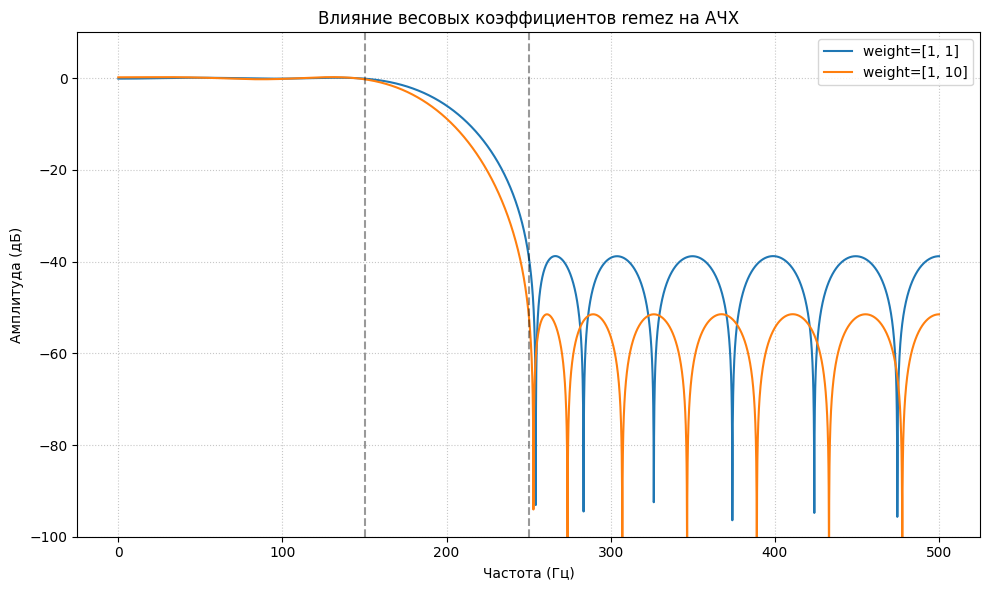

weight=[1, 1]: подавление = -38.8 дБ, пульсации в полосе пропускания = 0.199 дБ
weight=[1, 10]: подавление = -51.5 дБ, пульсации в полосе пропускания = 0.463 дБ


In [7]:
numtaps = 21

taps_w1 = remez(numtaps, [0, 150, 250, 500], [1, 0], weight=[1, 1],  fs=fs)
taps_w2 = remez(numtaps, [0, 150, 250, 500], [1, 0], weight=[1, 10], fs=fs)

plt.figure(figsize=(10, 6))
for taps, lbl in [(taps_w1, 'weight=[1, 1]'), (taps_w2, 'weight=[1, 10]')]:
    w, h = freqz(taps, worN=8000, fs=fs)
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), label=lbl)
plt.axvline(150, color='k', ls='--', alpha=0.4)
plt.axvline(250, color='k', ls='--', alpha=0.4)
plt.title('Влияние весовых коэффициентов remez на АЧХ')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 10)
plt.grid(True, which='both', ls=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

for taps, lbl in [(taps_w1, '[1, 1]'), (taps_w2, '[1, 10]')]:
    w, h = freqz(taps, worN=8000, fs=fs)
    stop = 20*np.log10(np.max(np.abs(h[w >= 250])))
    pb = np.abs(h[w <= 150])
    ripple = 20*np.log10(pb.max()) - 20*np.log10(pb.min())
    print(f'weight={lbl}: подавление = {stop:.1f} дБ, '
          f'пульсации в полосе пропускания = {ripple:.3f} дБ')

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

Подавление в полосе заграждения значительно улучшилось. Но произошло увеличение размаха равноволновых пульсаций в полосе пропускания.

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


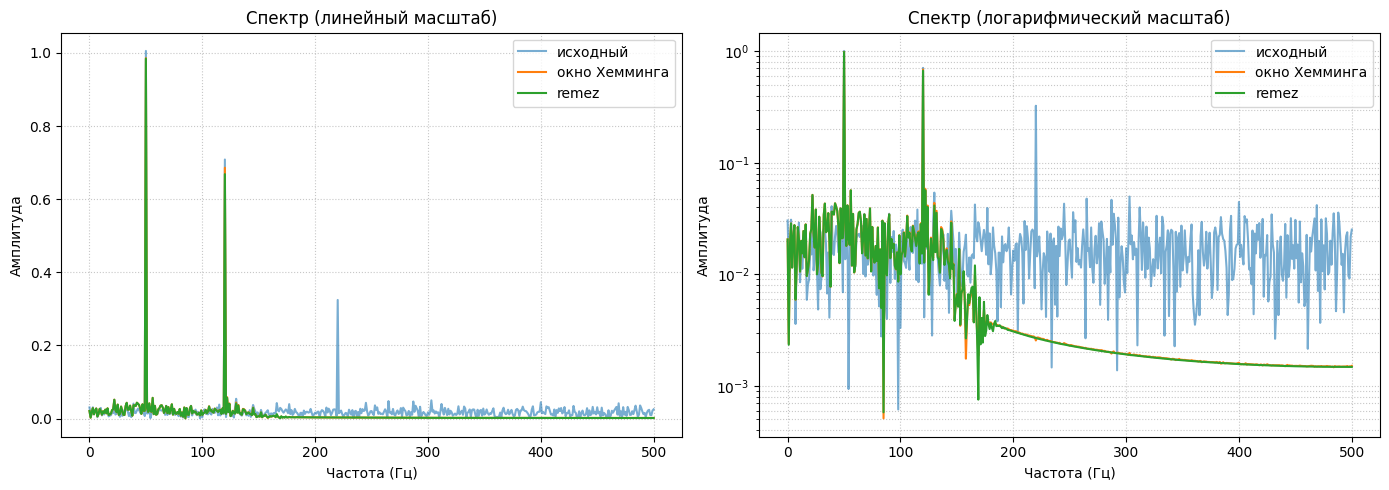

Амплитуда 120 Гц: исходная = 0.709
  окно Хемминга = 0.686 (отклонение -3.2%)
  remez         = 0.669 (отклонение -5.6%)
Амплитуда 220 Гц: исходная = 0.324, окно = 0.0026, remez = 0.0027


In [8]:
rng = np.random.default_rng(0)
t = np.arange(0, 1.0, 1/fs)
x = (1.0*np.sin(2*np.pi*50*t)
     + 0.7*np.sin(2*np.pi*120*t)
     + 0.3*np.sin(2*np.pi*220*t)
     + rng.normal(0, np.sqrt(0.1), len(t)))

h_win = firwin(51, 150.0, window='hamming', fs=fs)
h_rem = remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

y_win = lfilter(h_win, 1.0, x)
y_rem = lfilter(h_rem, 1.0, x)

def amp_spectrum(sig, fs):
    N = len(sig)
    f = np.fft.rfftfreq(N, 1/fs)
    A = np.abs(np.fft.rfft(sig)) / N * 2
    return f, A

f, Ax = amp_spectrum(x, fs)
_, Aw = amp_spectrum(y_win, fs)
_, Ar = amp_spectrum(y_rem, fs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(f, Ax, label='исходный', alpha=0.6)
plt.plot(f, Aw, label='окно Хемминга')
plt.plot(f, Ar, label='remez')
plt.title('Спектр (линейный масштаб)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(f, np.maximum(Ax, 1e-6), label='исходный', alpha=0.6)
plt.semilogy(f, np.maximum(Aw, 1e-6), label='окно Хемминга')
plt.semilogy(f, np.maximum(Ar, 1e-6), label='remez')
plt.title('Спектр (логарифмический масштаб)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

def amp_at(f, A, f0):
    return A[np.argmin(np.abs(f - f0))]
a0, aw, ar = amp_at(f, Ax, 120), amp_at(f, Aw, 120), amp_at(f, Ar, 120)
print(f'Амплитуда 120 Гц: исходная = {a0:.3f}')
print(f'  окно Хемминга = {aw:.3f} (отклонение {100*(aw-a0)/a0:+.1f}%)')
print(f'  remez         = {ar:.3f} (отклонение {100*(ar-a0)/a0:+.1f}%)')
print(f'Амплитуда 220 Гц: исходная = {amp_at(f,Ax,220):.3f}, '
      f'окно = {amp_at(f,Aw,220):.4f}, remez = {amp_at(f,Ar,220):.4f}')

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Составляющую 220 Гц и высокочастотный шум подавляют оба фильтра примерно одинаково. Частоту 120 Гц лучше сохраняет оконный фильтр Хемминга: при fc=150 Гц она ещё в полосе пропускания, а у remez полоса заканчивается на 100 Гц, поэтому 120 Гц попадает в переходную область. Амплитуда 120 Гц падает примерно на 3% у Хемминга и на 6% у remez.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


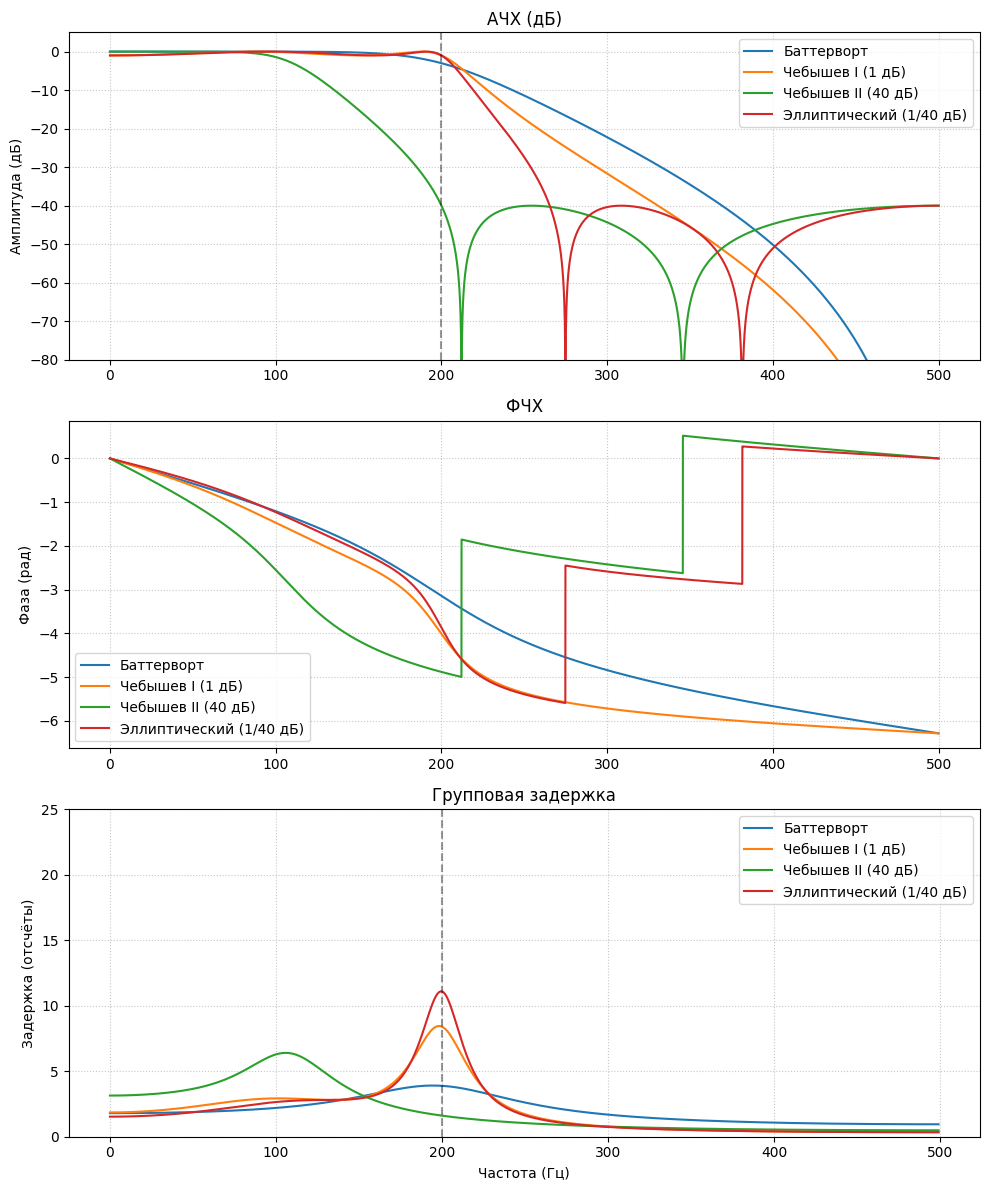

In [9]:
order = 4
fc = 200.0

filters = {
    'Баттерворт':              signal.butter(order, fc/nyq),
    'Чебышев I (1 дБ)':        signal.cheby1(order, 1, fc/nyq),
    'Чебышев II (40 дБ)':      signal.cheby2(order, 40, fc/nyq),
    'Эллиптический (1/40 дБ)': signal.ellip(order, 1, 40, fc/nyq),
}

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
for name, (b, a) in filters.items():
    w, h = freqz(b, a, worN=8000, fs=fs)
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), label=name)
plt.axvline(fc, color='k', ls='--', alpha=0.4)
plt.title('АЧХ (дБ)'); plt.ylabel('Амплитуда (дБ)')
plt.ylim(-80, 5); plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.subplot(3, 1, 2)
for name, (b, a) in filters.items():
    w, h = freqz(b, a, worN=8000, fs=fs)
    plt.plot(w, np.unwrap(np.angle(h)), label=name)
plt.title('ФЧХ'); plt.ylabel('Фаза (рад)')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.subplot(3, 1, 3)
for name, (b, a) in filters.items():
    gw, gd = group_delay((b, a), fs=fs)
    plt.plot(gw, gd, label=name)
plt.axvline(fc, color='k', ls='--', alpha=0.4)
plt.title('Групповая задержка'); plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)'); plt.ylim(0, 25)
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Самый крутой спад даёт эллиптический фильтр, потому что он допускает пульсации и в полосе пропускания, и в полосе заграждения. Наименьшие фазовые искажения у Баттерворта так как его АЧХ монотонная, а групповая задержка в полосе пропускания самая ровная. Строго линейной фазы у БИХ-фильтров нет.

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


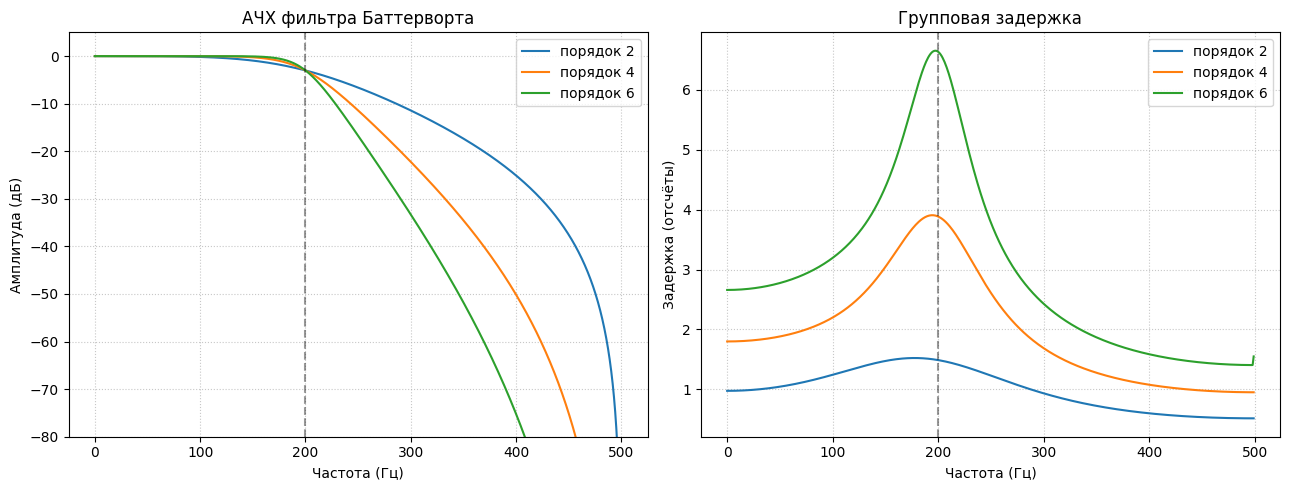

In [10]:
fc = 200.0
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
for order in [2, 4, 6]:
    b, a = signal.butter(order, fc/nyq)
    w, h = freqz(b, a, worN=8000, fs=fs)
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), label=f'порядок {order}')
plt.axvline(fc, color='k', ls='--', alpha=0.4)
plt.title('АЧХ фильтра Баттерворта'); plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)'); plt.ylim(-80, 5)
plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.subplot(1, 2, 2)
for order in [2, 4, 6]:
    b, a = signal.butter(order, fc/nyq)
    gw, gd = group_delay((b, a), fs=fs)
    plt.plot(gw, gd, label=f'порядок {order}')
plt.axvline(fc, color='k', ls='--', alpha=0.4)
plt.title('Групповая задержка'); plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

С ростом порядка срез становится круче, а подавление в полосе заграждения сильнее. Одновременно растёт групповая задержка, и у частоты среза появляется выраженный пик. То есть избирательность выше, но фазовые искажения больше.

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


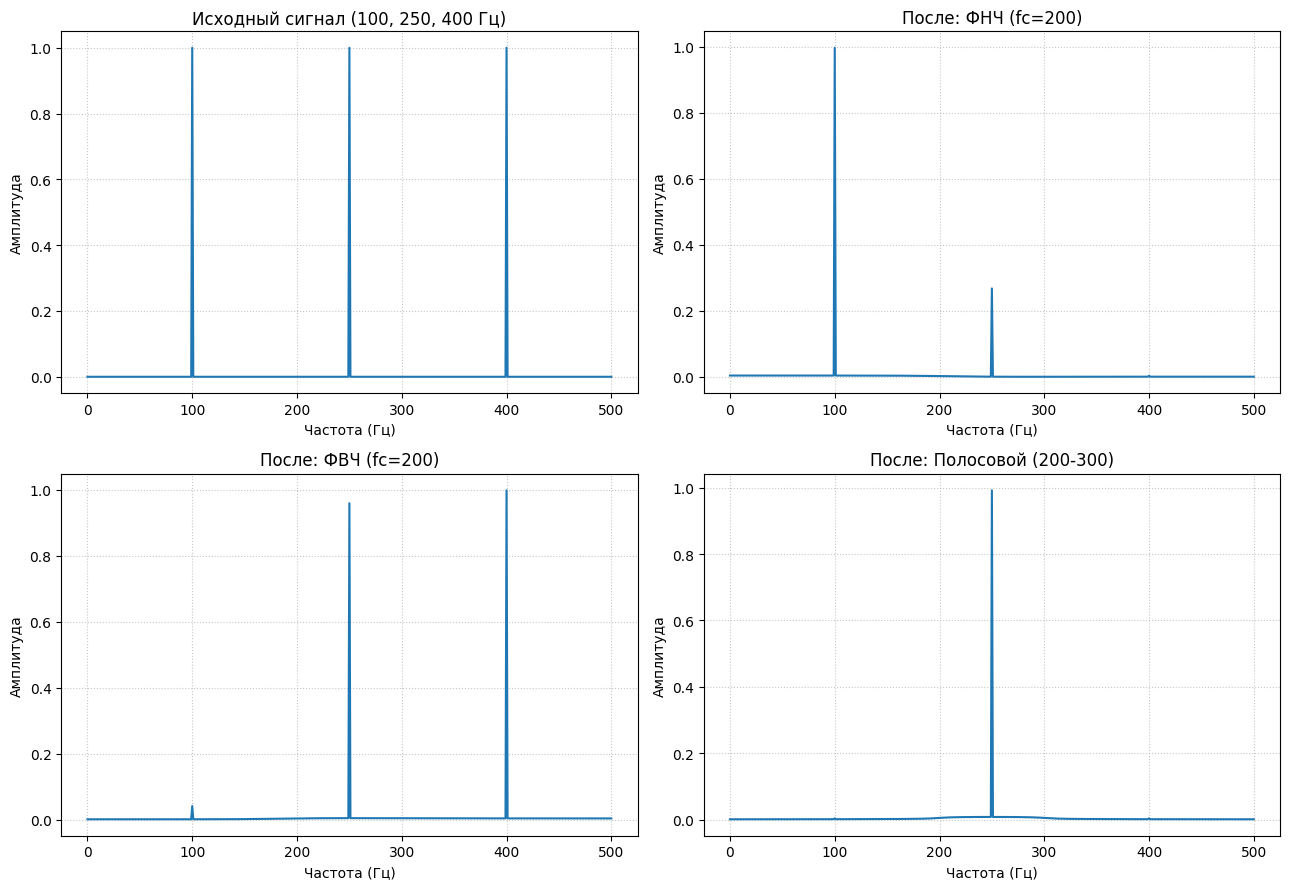

In [11]:
b_lp, a_lp = signal.butter(4, 200/nyq)
b_hp, a_hp = signal.butter(4, 200/nyq, btype='high')
b_bp, a_bp = signal.butter(4, [200/nyq, 300/nyq], btype='band')

t = np.arange(0, 1.0, 1/fs)
x = np.sin(2*np.pi*100*t) + np.sin(2*np.pi*250*t) + np.sin(2*np.pi*400*t)

def amp_spectrum(sig, fs):
    N = len(sig)
    f = np.fft.rfftfreq(N, 1/fs)
    A = np.abs(np.fft.rfft(sig)) / N * 2
    return f, A

f, Ax = amp_spectrum(x, fs)
filt = [('ФНЧ (fc=200)', b_lp, a_lp),
        ('ФВЧ (fc=200)', b_hp, a_hp),
        ('Полосовой (200-300)', b_bp, a_bp)]

plt.figure(figsize=(13, 9))

plt.subplot(2, 2, 1)
plt.plot(f, Ax)
plt.title('Исходный сигнал (100, 250, 400 Гц)')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.grid(True, ls=':', alpha=0.7)

for i, (name, b, a) in enumerate(filt, start=2):
    y = lfilter(b, a, x)
    _, A = amp_spectrum(y, fs)
    plt.subplot(2, 2, i)
    plt.plot(f, A)
    plt.title(f'После: {name}')
    plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
    plt.grid(True, ls=':', alpha=0.7)

plt.tight_layout()
plt.show()

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

ФНЧ пропускает 100 Гц и подавляет 250 и 400 Гц. ФВЧ наоборот подавляет 100 Гц и пропускает 250 и 400 Гц. Полосовой фильтр 200–300 Гц оставляет только 250 Гц, а 100 и 400 Гц подавляет.

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


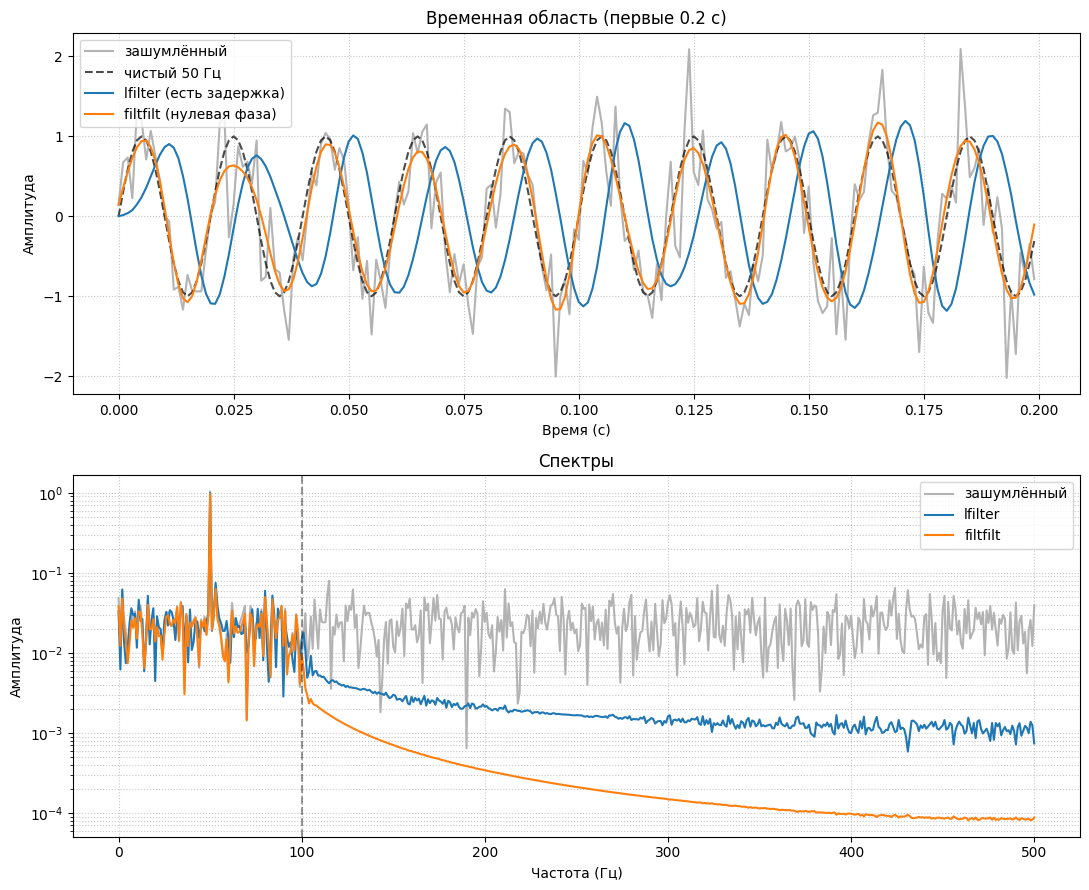

СКО: исходный = 0.857, lfilter = 0.726, filtfilt = 0.704


In [12]:
rng = np.random.default_rng(1)
t = np.arange(0, 1.0, 1/fs)
clean = np.sin(2*np.pi*50*t)
x = clean + rng.normal(0, np.sqrt(0.2), len(t))

b, a = signal.ellip(6, 1, 40, 100/nyq)

y_lf = lfilter(b, a, x)
y_ff = filtfilt(b, a, x)

def amp_spectrum(sig, fs):
    N = len(sig)
    f = np.fft.rfftfreq(N, 1/fs)
    A = np.abs(np.fft.rfft(sig)) / N * 2
    return f, A

plt.figure(figsize=(11, 9))

n = int(0.2 * fs)
plt.subplot(2, 1, 1)
plt.plot(t[:n], x[:n], color='0.7', label='зашумлённый')
plt.plot(t[:n], clean[:n], 'k--', alpha=0.7, label='чистый 50 Гц')
plt.plot(t[:n], y_lf[:n], label='lfilter (есть задержка)')
plt.plot(t[:n], y_ff[:n], label='filtfilt (нулевая фаза)')
plt.title('Временная область (первые 0.2 с)')
plt.xlabel('Время (с)'); plt.ylabel('Амплитуда')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

f, Ax = amp_spectrum(x, fs)
_, Al = amp_spectrum(y_lf, fs)
_, Af = amp_spectrum(y_ff, fs)
plt.subplot(2, 1, 2)
plt.semilogy(f, np.maximum(Ax, 1e-6), color='0.7', label='зашумлённый')
plt.semilogy(f, np.maximum(Al, 1e-6), label='lfilter')
plt.semilogy(f, np.maximum(Af, 1e-6), label='filtfilt')
plt.axvline(100, color='k', ls='--', alpha=0.4)
plt.title('Спектры')
plt.xlabel('Частота (Гц)'); plt.ylabel('Амплитуда')
plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

print(f'СКО: исходный = {x.std():.3f}, lfilter = {y_lf.std():.3f}, filtfilt = {y_ff.std():.3f}')

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

filtfilt фильтрует сигнал дважды сначала вперёд, потом назад. При обратном проходе фазовый сдвиг прямого прохода компенсируется, поэтому суммарная фаза нулевая и задержки нет.

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


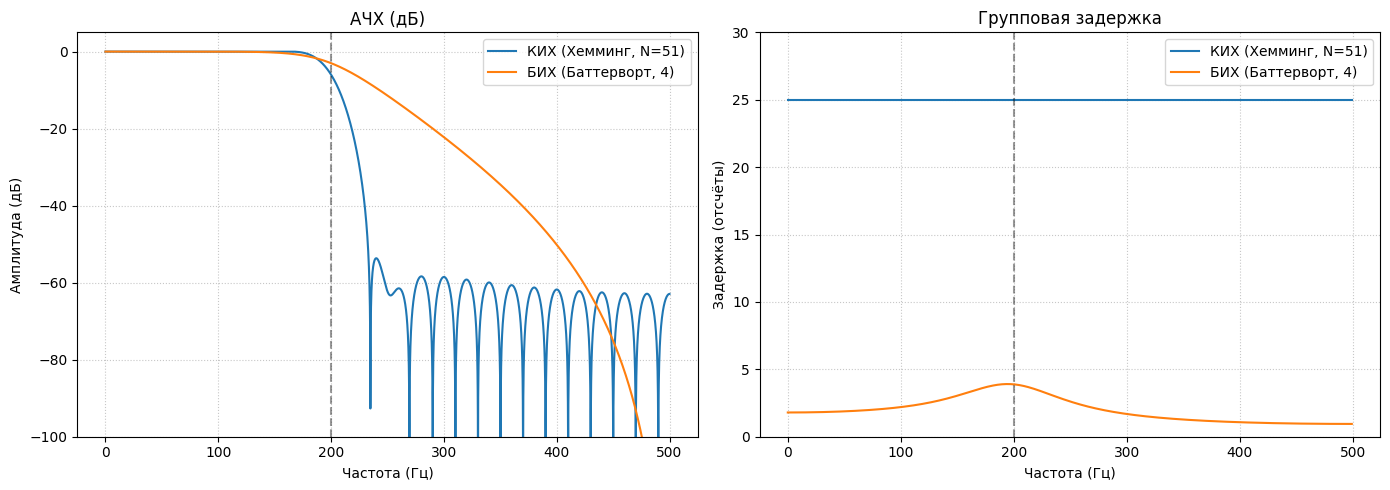

КИХ: максимум АЧХ в полосе заграждения 250-500 Гц = -58.4 дБ
Баттерворт порядка  2: максимум в ПЗ [250-500] = -6.6 дБ
Баттерворт порядка  3: максимум в ПЗ [250-500] = -8.9 дБ
Баттерворт порядка  4: максимум в ПЗ [250-500] = -11.4 дБ
Баттерворт порядка  5: максимум в ПЗ [250-500] = -14.0 дБ
Баттерворт порядка  6: максимум в ПЗ [250-500] = -16.7 дБ
Баттерворт порядка  7: максимум в ПЗ [250-500] = -19.5 дБ
Баттерворт порядка  8: максимум в ПЗ [250-500] = -22.2 дБ
Баттерворт порядка  9: максимум в ПЗ [250-500] = -25.0 дБ
Баттерворт порядка 10: максимум в ПЗ [250-500] = -27.8 дБ
Баттерворт порядка 11: максимум в ПЗ [250-500] = -30.5 дБ
Баттерворт порядка 12: максимум в ПЗ [250-500] = -33.3 дБ
Баттерворт порядка 13: максимум в ПЗ [250-500] = -36.1 дБ
Баттерворт порядка 14: максимум в ПЗ [250-500] = -38.8 дБ
Баттерворт порядка 15: максимум в ПЗ [250-500] = -41.6 дБ
Баттерворт порядка 16: максимум в ПЗ [250-500] = -44.4 дБ
Баттерворт порядка 17: максимум в ПЗ [250-500] = -47.2 дБ
Баттерворт по

In [13]:
h_fir = firwin(51, 200.0, window='hamming', fs=fs)
b_iir, a_iir = signal.butter(4, 200/nyq)

w_f, h_f = freqz(h_fir, worN=8000, fs=fs)
w_i, h_i = freqz(b_iir, a_iir, worN=8000, fs=fs)
gwf, gdf = group_delay((h_fir, 1.0), fs=fs)
gwi, gdi = group_delay((b_iir, a_iir), fs=fs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(w_f, 20*np.log10(np.maximum(np.abs(h_f), 1e-10)), label='КИХ (Хемминг, N=51)')
plt.plot(w_i, 20*np.log10(np.maximum(np.abs(h_i), 1e-10)), label='БИХ (Баттерворт, 4)')
plt.axvline(200, color='k', ls='--', alpha=0.4)
plt.title('АЧХ (дБ)'); plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)'); plt.ylim(-100, 5)
plt.grid(True, which='both', ls=':', alpha=0.7); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gwf, gdf, label='КИХ (Хемминг, N=51)')
plt.plot(gwi, gdi, label='БИХ (Баттерворт, 4)')
plt.axvline(200, color='k', ls='--', alpha=0.4)
plt.title('Групповая задержка'); plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)'); plt.ylim(0, 30)
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

fir_stop = np.max(20*np.log10(np.maximum(np.abs(h_f[w_f >= 250]), 1e-10)))
print(f'КИХ: максимум АЧХ в полосе заграждения 250-500 Гц = {fir_stop:.1f} дБ')
match_order = None
for order in range(2, 27):
    b, a = signal.butter(order, 200/nyq)
    w, h = freqz(b, a, worN=8000, fs=fs)
    iir_stop = np.max(20*np.log10(np.maximum(np.abs(h[w >= 250]), 1e-10)))
    print(f'Баттерворт порядка {order:2d}: максимум в ПЗ [250-500] = {iir_stop:.1f} дБ')
    if match_order is None and iir_stop <= fir_stop:
        match_order = order
print(f'Сравнимое с КИХ подавление в полосе заграждения достигается примерно при порядке {match_order}.')

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Более крутой срез и постоянную групповую задержку имеет КИХ-фильтр: у него линейная фаза, поэтому форма сигнала искажается меньше. БИХ-фильтр Баттерворта требует меньше вычислений. Чтобы его подавление во всей полосе заграждения стало сравнимым с КИХ, порядок приходится поднимать примерно до 22, и при этом фазовые искажения и неравномерность групповой задержки растут.

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


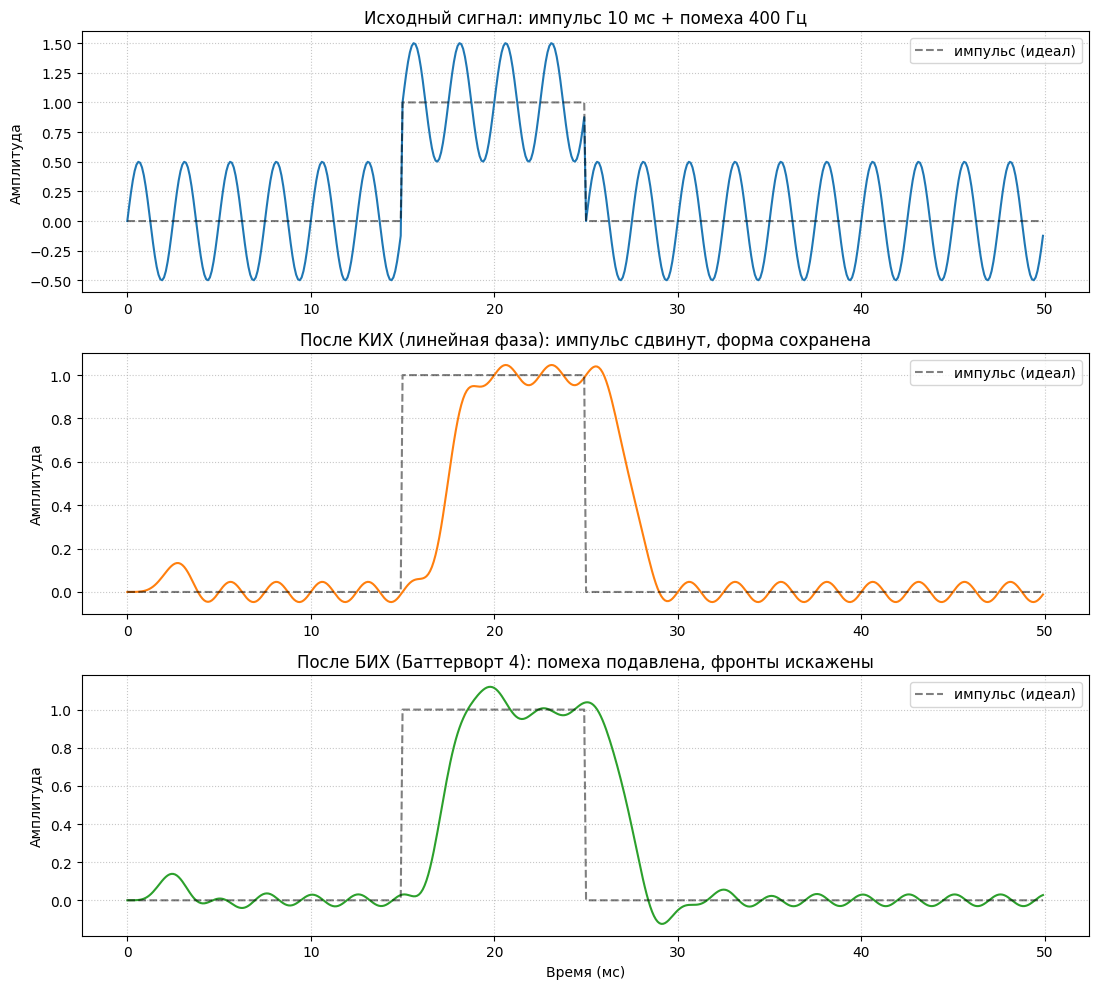

In [14]:
fs2 = 10000.0
t = np.arange(0, 0.05, 1/fs2)

pulse = ((t >= 0.015) & (t < 0.025)).astype(float)
interf = 0.5*np.sin(2*np.pi*400*t)
x = pulse + interf

h_fir = firwin(51, 200.0, window='hamming', fs=fs2)
b_iir, a_iir = signal.butter(4, 200/(fs2/2))

y_fir = lfilter(h_fir, 1.0, x)
y_iir = lfilter(b_iir, a_iir, x)

plt.figure(figsize=(11, 10))

plt.subplot(3, 1, 1)
plt.plot(t*1e3, x)
plt.plot(t*1e3, pulse, 'k--', alpha=0.5, label='импульс (идеал)')
plt.title('Исходный сигнал: импульс 10 мс + помеха 400 Гц')
plt.ylabel('Амплитуда'); plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t*1e3, y_fir, color='C1')
plt.plot(t*1e3, pulse, 'k--', alpha=0.5, label='импульс (идеал)')
plt.title('После КИХ (линейная фаза): импульс сдвинут, форма сохранена')
plt.ylabel('Амплитуда'); plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t*1e3, y_iir, color='C2')
plt.plot(t*1e3, pulse, 'k--', alpha=0.5, label='импульс (идеал)')
plt.title('После БИХ (Баттерворт 4): помеха подавлена, фронты искажены')
plt.xlabel('Время (мс)'); plt.ylabel('Амплитуда')
plt.grid(True, ls=':', alpha=0.7); plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

Форму импульса лучше сохраняет КИХ-фильтр благодаря линейной фазе, фронты не искажаются, импульс только сдвигается во времени. Помеху 400 Гц подавляют оба фильтра, но у БИХ из-за нелинейной фазы форма импульса искажается заметнее.